# The Perfect Macro Forecaster — a quantitative teardown 🔬
### Lead-lag · an oracle at every information horizon · block bootstrap · rotation placebo · the ceiling

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Stocks lead the economy?: Confirmed](https://img.shields.io/badge/Stocks_lead_the_economy%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We grant
perfect, final-vintage foresight of US macro (real GDP growth, Δunemployment, CPI inflation,
ΔT-bill; `statsmodels` `macrodata`, 1959Q1–2009Q3) and measure what it is worth for timing the
US market (Fama-French `Mkt-RF + RF`, **total return**, monthly compounded to quarters). The
decisive comparisons are **§3** (the oracle grid with inference) and **§4** (same quarter vs one
quarter beyond).

> ⚠️ **Not investment advice.** Headline numbers mirror the pinned run in
> [`docs/results.md`](../docs/results.md) (as-of 2009-09-30, fingerprint
> `6008ef31746a`); the cells below recompute them on the same bundled tapes (bootstrap
> draws reduced for speed, so third-decimal p-values may differ).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
GOOD, AMBER, BAD, BLUE, GREY = "#2ea44f", "#dab617", "#c0392b", "#1f6feb", "#8b949e"

from clairvoyance import data, strategy as st
panel = data.load_panel()
print(f"as-of {data.AS_OF} | {len(panel)} quarters {panel.index[0].date()} -> "
      f"{panel.index[-1].date()} | fingerprint {data.fingerprint(panel[['mkt','rf','g','du','infl','dtb']])}")

as-of 2009-09-30 | 202 quarters 1959-06-30 -> 2009-09-30 | fingerprint 6008ef31746a


## Verdict, up front

| Axis | Stamp | Decisive numbers |
|---|---|---|
| **Signal** — is perfect coming-quarter macro foresight worth something? | None | Combined oracle h = 0: Sharpe 0.29 vs B&H 0.25, ΔSharpe +0.04, bootstrap p = 0.40, rotation p = 0.12. At h = +1: 0.47 (p = 0.09 / 0.01) — suggestive, not certified. GDP alone at h = +1: 0.58 (p = 0.02 / 0.006). |
| **Tradability** — what survives the release lag? | Fragile | h = −1: 0.48 (ΔSharpe +0.23, bootstrap p = 0.08); h = −2: 0.13 (ΔSharpe −0.12). Final vintage caps the stamp at Fragile. |
| **Stocks lead the economy?** | Confirmed | corr(ex_t, g_t+k): k=0 +0.07 (t +0.8), k=+1 +0.27 (t +3.6), k=+2 +0.34 (t +4.4). |

Ceiling (perfect market oracle): **1.53**. Window 1964Q4–2009Q1, 178 quarters,
identical for every rule.

> 💡 **In plain words.** A perfect economic forecast for the coming quarter is already in
> the price. You would need to see further than the market does — and nobody does.

## 1 · Hypotheses (fixed before the run)

- **H₁ (the claim).** The combined oracle at h = 0 beats buy-and-hold net of 10 bps, with
  bootstrap p < 0.05 **and** rotation p < 0.05 → Signal Real. If not, but h = +1 does → Mixed.
- **H₂ (markets price the future).** The excess return correlates with GDP growth one or two
  quarters *later* (NW *t* ≥ 2) more than with the same quarter.
- **H₃ (what is knowable).** The combined oracle at h = −1 beats buy-and-hold with bootstrap
  p < 0.10 → Fragile, else Mirage. Never Investable on final-vintage data.

**Execution lag.** One: the position for quarter *t* is fixed at the close of *t − 1*. All
look-ahead lives in the oracle's *h*. Costs one-way × |Δposition| × NAV.

## 2 · Lead-lag: who moves first

corr(excess return_t, x_{t+k})  (Newey-West t, 4 lags)
                             k=-4          k=-3          k=-2          k=-1          k=+0          k=+1          k=+2          k=+3          k=+4
real GDP growth      -0.05 (-0.7)  -0.13 (-2.1)  -0.12 (-1.8)  -0.03 (-0.4)  +0.07 (+0.8)  +0.27 (+3.6)  +0.34 (+4.4)  +0.20 (+2.5)  +0.13 (+2.1)
unemployment change  +0.06 (+0.9)  +0.10 (+1.7)  +0.13 (+1.6)  +0.14 (+1.9)  +0.06 (+0.6)  -0.22 (-2.8)  -0.36 (-5.4)  -0.40 (-6.9)  -0.26 (-5.3)
CPI inflation        -0.05 (-0.7)  -0.15 (-1.6)  -0.04 (-0.4)  -0.08 (-1.0)  -0.13 (-1.2)  -0.08 (-0.9)  -0.01 (-0.2)  +0.01 (+0.1)  -0.02 (-0.4)
T-bill change        -0.06 (-0.8)  -0.05 (-0.7)  -0.05 (-0.9)  -0.13 (-2.3)  -0.10 (-1.5)  +0.18 (+3.4)  +0.17 (+2.7)  +0.01 (+0.2)  +0.05 (+1.0)


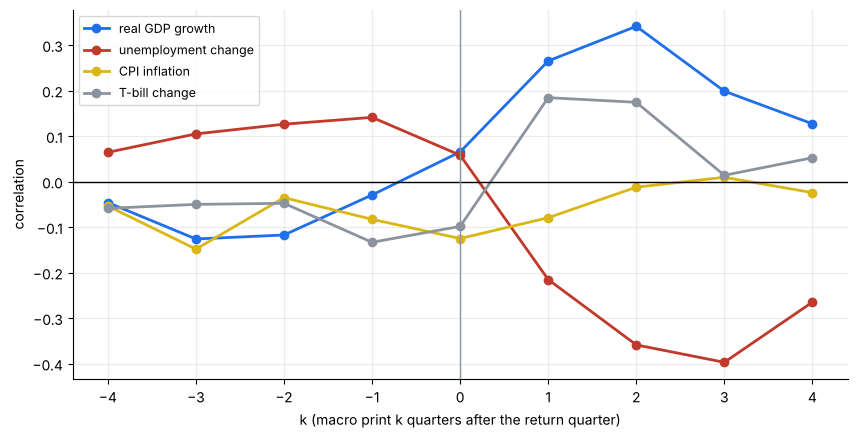

In [2]:
rows = {}
for v in data.MACRO_VARS:
    L = st.lead_lag(panel, v)
    rows[data.LABELS[v]] = [f"{c:+.2f} ({t:+.1f})" for c, t in zip(L["corr"], L["t"])]
LL = pd.DataFrame(rows, index=[f"k={k:+d}" for k in range(-4, 5)]).T
print("corr(excess return_t, x_{t+k})  (Newey-West t, 4 lags)")
print(LL.to_string())

fig, ax = plt.subplots(figsize=(10, 4.8))
for v, c in zip(data.MACRO_VARS, (BLUE, BAD, AMBER, GREY)):
    L = st.lead_lag(panel, v)
    ax.plot(L.index, L["corr"], "o-", lw=2, color=c, label=data.LABELS[v])
ax.axhline(0, color="k", lw=1); ax.axvline(0, color=GREY, lw=1)
ax.set_xlabel("k (macro print k quarters after the return quarter)")
ax.set_ylabel("correlation"); ax.legend(fontsize=9)
plt.show()

> 💡 **In plain words.** GDP and unemployment line up with *future* stock returns'
> mirror image: this quarter's market move is about the economy six months from now. Inflation
> barely lines up with anything at the quarterly frequency.

Checking that the HAC *t* is honestly sized when the regressor is autocorrelated:

In [3]:
print(st.lead_lag_size(n_seeds=200))

{'n_seeds': 200, 'reject_rate': 0.06, 'sd_t': 1.0899977054137653}


## 3 · The oracle grid, with inference

In [4]:
T, win = st.horizon_table(panel, n_boot=1000)
sub = panel.loc[win]
bh = st.ann_sharpe(sub["ex"])
ceil = st.ann_sharpe(st.book(st.market_oracle(sub), sub["ex"]))
print(f"window {win[0].date()} -> {win[-1].date()} ({len(win)} quarters); B&H {bh:.2f}; ceiling {ceil:.2f}")
show = T[["var", "h", "sharpe", "dsharpe", "ci_lo", "ci_hi", "boot_p", "rot_p", "active_t",
          "exposure", "switches_per_year", "hit_rate", "capture"]]
print(show.round(3).to_string(index=False))
print(f"\ncells clearing both nulls at 5%: {sum(st.passes(r) for r in T.to_dict('records'))} of {len(T)}")

window 1964-12-31 -> 2009-03-31 (178 quarters); B&H 0.25; ceiling 1.53
     var  h  sharpe  dsharpe  ci_lo  ci_hi  boot_p  rot_p  active_t  exposure  switches_per_year  hit_rate  capture
       g -2  -0.051   -0.302 -0.574 -0.060   0.988  0.977    -2.482     0.433              1.618     0.449   -0.237
      du -2   0.094   -0.157 -0.451  0.139   0.855  0.698    -1.523     0.444              1.326     0.494   -0.123
    infl -2   0.301    0.050 -0.194  0.321   0.337  0.128    -0.537     0.466              0.989     0.528    0.039
     dtb -2   0.249   -0.002 -0.248  0.236   0.488  0.227    -0.656     0.528              1.393     0.522   -0.002
combined -2   0.127   -0.124 -0.430  0.195   0.794  0.558    -1.379     0.444              1.056     0.517   -0.097
       g -1   0.278    0.027 -0.267  0.320   0.431  0.122    -0.788     0.433              1.596     0.483    0.021
      du -1   0.350    0.099 -0.188  0.405   0.265  0.058    -0.414     0.438              1.326     0.545    0.078
 

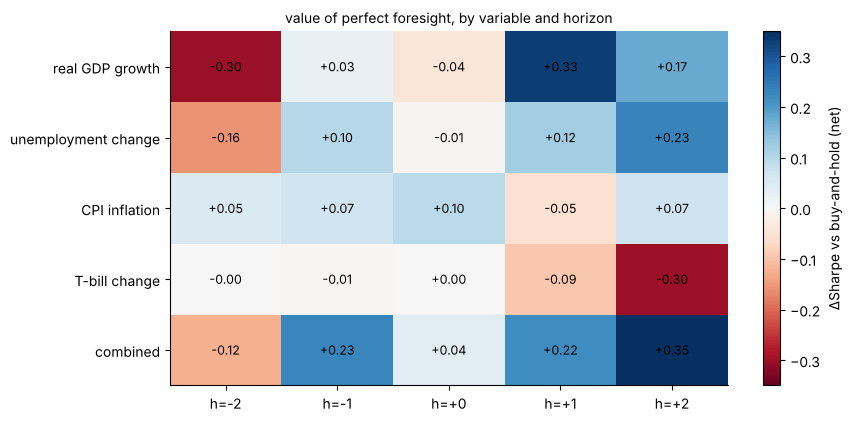

In [5]:
piv = T.pivot(index="var", columns="h", values="dsharpe").loc[["g", "du", "infl", "dtb", "combined"]]
fig, ax = plt.subplots(figsize=(9, 4.6))
lim = np.abs(piv.to_numpy()).max()
im = ax.imshow(piv.to_numpy(), cmap="RdBu", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f"h={h:+d}" for h in piv.columns])
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels([data.LABELS.get(v, v) for v in piv.index])
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.iloc[i, j]:+.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="ΔSharpe vs buy-and-hold (net)")
ax.set_title("value of perfect foresight, by variable and horizon", fontsize=10)
ax.grid(False)
plt.show()

> 💡 **In plain words.** Blue cells beat holding the market. The h = 0 column — a
> perfect forecast of the quarter you hold — is pale. The colour lives to the right (seeing
> beyond the quarter) and, for the combined vote, oddly at h = −1, which §5 takes apart.

### 3.1 The rotation placebo, drawn

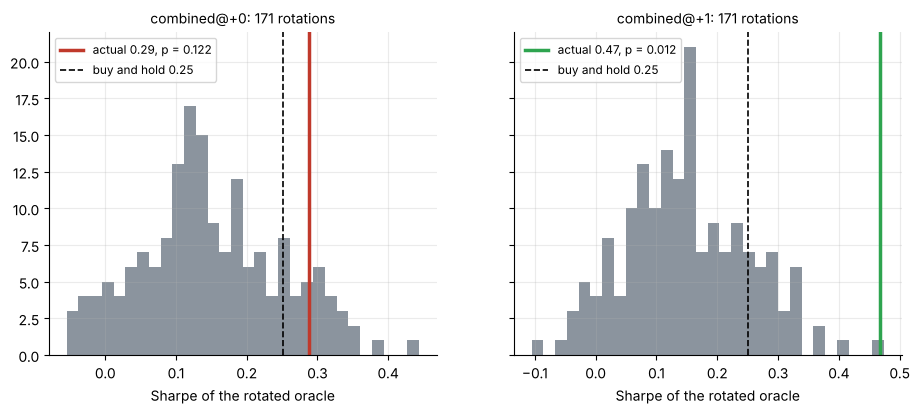

In [6]:
P = st.all_positions(panel).loc[win]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, name in zip(axes, ("combined@+0", "combined@+1")):
    rt = st.rotation_test(P[name], sub["ex"])
    ax.hist(rt["null"], bins=30, color=GREY)
    ax.axvline(rt["sharpe"], color=BAD if rt["p"] > 0.05 else GOOD, lw=2.5,
               label=f"actual {rt['sharpe']:.2f}, p = {rt['p']:.3f}")
    ax.axvline(bh, color="k", ls="--", lw=1.2, label=f"buy and hold {bh:.2f}")
    ax.set_title(f"{name}: {rt['n_rot']} rotations", fontsize=10)
    ax.set_xlabel("Sharpe of the rotated oracle"); ax.legend(fontsize=8.5)
plt.show()

## 4 · Same quarter vs one quarter beyond — the market prices the future

In [7]:
for v in ("g", "du", "combined"):
    a = st.book(P[f"{v}@+1"], sub["ex"]); b = st.book(P[f"{v}@+0"], sub["ex"])
    bt = st.sharpe_diff_bootstrap(a.to_numpy(), b.to_numpy(), n_boot=1000)
    print(f"{v:9s} h=+1 {st.ann_sharpe(a):.2f} vs h=0 {st.ann_sharpe(b):.2f}   "
          f"diff {bt['dsharpe']:+.2f}  95% CI [{bt['ci_lo']:+.2f}, {bt['ci_hi']:+.2f}]  p={bt['p']:.3f}")

g         h=+1 0.58 vs h=0 0.21   diff +0.37  95% CI [+0.12, +0.64]  p=0.004
du        h=+1 0.37 vs h=0 0.24   diff +0.13  95% CI [-0.06, +0.33]  p=0.099
combined  h=+1 0.47 vs h=0 0.29   diff +0.18  95% CI [+0.00, +0.38]  p=0.042


For GDP the step from h = 0 to h = +1 is worth +0.37 of Sharpe (bootstrap
p = 0.004). This is the study's mechanism: the quarter-ahead forecast the
industry produces is exactly the horizon the market has already discounted.

> 💡 **In plain words.** Knowing *today's* weather perfectly doesn't help you bet on
> umbrellas — the umbrella shops already stocked up last week.

## 5 · What a real investor could know — the release lag

In [8]:
r = T[(T["var"] == "combined") & (T["h"].isin([-2, -1]))][["h", "sharpe", "dsharpe", "boot_p", "rot_p", "active_t"]]
print(r.round(3).to_string(index=False))
print()
print(st.cost_sweep(P["combined@-1"], sub).round(3).to_string())
print()
print(st.subperiods(P["combined@-1"], sub).round(3).to_string())

 h  sharpe  dsharpe  boot_p  rot_p  active_t
-2   0.127   -0.124   0.794  0.558    -1.379
-1   0.479    0.228   0.089  0.006     0.064



          sharpe  dsharpe  boot_p
cost_bps                         
0          0.490    0.239   0.078
10         0.479    0.228   0.089
25         0.463    0.212   0.106
50         0.436    0.184   0.134

                          n  sharpe  bh_sharpe  dsharpe  boot_p
period                                                         
first half (1964-1986)   89   0.400      0.219    0.182   0.193
second half (1987-2009)  89   0.547      0.283    0.264   0.115


Three red flags on the lagged rule: (1) one more quarter of lag turns 0.48 into
0.13; (2) the Newey-West *t* of the active return is ≈ 0, so the Sharpe gain is a
volatility-avoidance effect, not extra return; (3) it is one of 10 realistic cells, on
**final-vintage** data. Revisions to GDP growth routinely exceed a percentage point (annualised),
large enough to flip an above/below-median call. Hence **Fragile**, capped by construction.

> 💡 **In plain words.** The version you could actually run looks okay only if you
> squint, use numbers nobody had at the time, and get the timing exactly right.

## 6 · The ceiling

            hit_rate  sharpe  dsharpe
error_rate                           
0.000          1.000   1.526    1.274
0.100          0.900   1.170    0.919
0.200          0.800   0.867    0.615
0.300          0.700   0.616    0.364
0.400          0.600   0.382    0.130


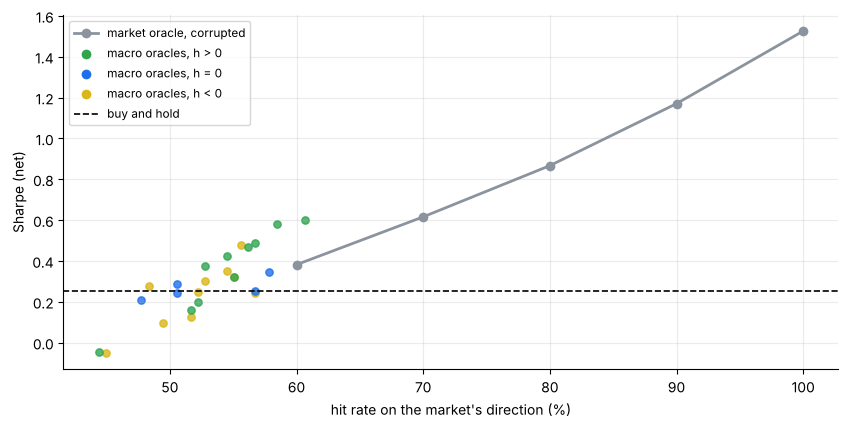

In [9]:
lad = st.ceiling_ladder(panel, win)
print(lad.round(3).to_string())
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(lad["hit_rate"] * 100, lad["sharpe"], "o-", color=GREY, lw=2, label="market oracle, corrupted")
for _, r in T.iterrows():
    c = GOOD if r["h"] > 0 else (BLUE if r["h"] == 0 else AMBER)
    ax.scatter(r["hit_rate"] * 100, r["sharpe"], color=c, s=28, alpha=0.8)
ax.scatter([], [], color=GOOD, label="macro oracles, h > 0")
ax.scatter([], [], color=BLUE, label="macro oracles, h = 0")
ax.scatter([], [], color=AMBER, label="macro oracles, h < 0")
ax.axhline(bh, color="k", ls="--", lw=1.2, label="buy and hold")
ax.set_xlabel("hit rate on the market's direction (%)"); ax.set_ylabel("Sharpe (net)")
ax.legend(fontsize=8.5)
plt.show()

> 💡 **In plain words.** All 25 macro oracles sit in a cloud between 45% and 61% hit
> rates — the "barely better than a coin" region — far from the 100% corner.

## 7 · Synthetic control — the machinery, not the market

In [10]:
sp = st.synthetic_power(seeds=range(1014, 1020), n_boot=300)
print(sp.groupby("signal_strength")[["dsharpe", "boot_p", "rot_p", "passes", "lead_t"]].mean().round(3).to_string())

                 dsharpe  boot_p  rot_p  passes  lead_t
signal_strength                                        
0.000             -0.122   0.749  0.452   0.000   0.331
1.000              0.391   0.002  0.003   1.000   9.856


With the lead planted (strength 1) the GDP h = +1 oracle clears both nulls in every seed; on the
matched null (strength 0) it does not. A harness that can bank a planted effect and refuses a
null one is the precondition for reading its "no" on the real tape as a real "no".

## 8 · Caveats

- **Final vintage.** `macrodata` is revised data. T-bills are never revised, CPI barely,
  unemployment only via seasonal factors; GDP heavily. Every h < 0 number is an upper bound.
- **Generous release lag.** h = −1 assumes last quarter's GDP is known at quarter start; the
  advance estimate arrives ~4 weeks later.
- **One rule family.** Median split, all-in/all-out. Graded rules could extract more; the ceiling
  bounds any of them.
- **Multiplicity.** 25 cells; the verdict uses three pre-registered ones.
- **Sample.** 1964–2009, US, ~8 recessions.

## 9 · Verdict, could you trade it, going further

**Signal: None** · **Tradability: Fragile** · **Stocks lead the economy? Confirmed.**

> **In one sentence:** Even a flawless forecast of the coming quarter's GDP, jobs and inflation would have timed US stocks to a Sharpe of 0.29 against 0.25 for buying and holding, because the market had already moved on to pricing the quarter after — only an oracle that sees that far (0.47) starts to earn its fee; the lagged rule a real investor could run looks better on paper (0.48) but loses to buy-and-hold with one more quarter of lag (0.13).

**Could you trade it?** No version that uses information you could have had beats the market
robustly; costs are irrelevant at ~1 switch a year; capacity is irrelevant for an index timer.
The binding constraints are the information set and the revisions.

**Going further.**
- Rerun h = −1 on the Philadelphia Fed real-time dataset (first-release GDP).
- Replace the oracle with the Survey of Professional Forecasters consensus.
- Graded rules: regress the excess return on the oracle value with an expanding window.
- Invert the question: the market as a forecaster of GDP (Fama 1990's direction).